# Decision Intelligence Evolution - Keyword Trends and Co-occurrence Analysis

**Execution Order: 3 of 3**

This notebook performs:
1. Keyword extraction from titles, abstracts, and author keywords
2. Temporal trends analysis of key terms
3. Co-occurrence network mapping
4. Network visualization (VOSviewer-style)
5. Visualization of keyword evolution

**Prerequisites**: 
- Run `01_data_preparation.ipynb` first to generate the dataset WITH abstracts
- The file `output/decision_intelligence_with_abstracts.csv` must exist

**Note**: This analysis uses abstracts which are NOT committed to Git.

## 1. Setup and Imports

In [30]:
!pip install networkx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from collections import Counter, defaultdict
import re
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Directories
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

print("✓ Libraries imported successfully")
print(f"✓ Output directory: {OUTPUT_DIR.absolute()}")

✓ Libraries imported successfully
✓ Output directory: /Users/wisu/Source/citrus-decision-intelligence/output


## 2. Load Data with Abstracts

In [31]:
# Load the dataset WITH abstracts
data_file = OUTPUT_DIR / 'decision_intelligence_with_abstracts.csv'

if not data_file.exists():
    print("❌ ERROR: File with abstracts not found!")
    print("   Please run notebook 01_data_preparation.ipynb first.")
    raise FileNotFoundError(f"Required file not found: {data_file}")

df = pd.read_csv(data_file, encoding='utf-8')

print(f"✓ Loaded {len(df)} records")
print(f"  Records with abstracts: {df['abstract'].notna().sum()}")
print(f"  Records with keywords: {df['keywords'].notna().sum()}")
print(f"  Year range: {df['year'].min():.0f} - {df['year'].max():.0f}")

✓ Loaded 432 records
  Records with abstracts: 431
  Records with keywords: 381
  Year range: 2010 - 2026


## 3. Keyword Extraction and Preprocessing

In [32]:
def extract_keywords_from_text(text, min_length=3):
    """Extract meaningful technical keywords from text. Focuses ONLY on multi-word technical terms."""
    if pd.isna(text):
        return []
    
    stopwords = {
        'the', 'and', 'for', 'with', 'this', 'that', 'from', 'are', 'was', 'were',
        'been', 'have', 'has', 'had', 'can', 'will', 'would', 'could', 'should',
        'may', 'might', 'must', 'shall', 'our', 'their', 'these', 'those', 'such',
        'into', 'through', 'during', 'before', 'after', 'however', 'moreover',
        'furthermore', 'therefore', 'additionally', 'finally', 'first', 'second',
        'third', 'next', 'then', 'thus', 'hence', 'consequently', 'accordingly',
        'meanwhile', 'subsequently', 'specifically', 'particularly', 'especially',
        'notably', 'using', 'based', 'results', 'research', 'study', 'studies',
        'paper', 'article', 'work', 'approach', 'method', 'methods', 'analysis',
        'data', 'information', 'system', 'systems', 'model', 'models', 'framework',
        'process', 'processes', 'while', 'although', 'though', 'since', 'because',
        'when', 'where', 'which', 'what', 'who', 'how', 'why', 'all', 'some',
        'many', 'most', 'few', 'several', 'various', 'different', 'same', 'other',
        'another', 'each', 'every', 'traditional', 'experimental', 'proposed',
        'novel', 'new', 'existing', 'current', 'recent', 'previous', 'future',
        'author', 'authors', 'et', 'al', 'decision', 'intelligence', 'design',
        'multi', 'findings', 'large', 'industry', 'science', 'purpose', 'internet',
        'originality', 'things', 'despite', 'scopus', 'language', 'digital',
        'extensive', 'making', 'artificial', 'business', 'value', 'practical',
        'implications', 'limitations', 'contribution', 'contributions'
    }
    
    multi_word_pattern = r'\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+){1,4}\b'
    multi_words = re.findall(multi_word_pattern, str(text))
    
    keywords = []
    for phrase in multi_words:
        phrase_lower = phrase.lower()
        words_in_phrase = phrase_lower.split()
        if any(w in stopwords for w in words_in_phrase):
            continue
        if len(words_in_phrase) < 2:
            continue
        if len(phrase) < min_length:
            continue
        keywords.append(phrase)
    
    return keywords

def parse_author_keywords(keywords_str):
    """Parse author-provided keywords from various formats."""
    if pd.isna(keywords_str):
        return []
    keywords = re.split(r'[;,|]', str(keywords_str))
    cleaned = []
    for kw in keywords:
        kw = kw.strip()
        if len(kw) > 2:
            cleaned.append(kw.title())
    return cleaned

print("✓ Keyword extraction functions defined")

✓ Keyword extraction functions defined


In [33]:
# Manual exclusion list for publishers, metadata, and non-technical terms
MANUAL_EXCLUSIONS = {
    'elsevier ltd', 'elsevier', 'springer nature switzerland', 'springer nature',
    'springer', 'ieee', 'wiley', 'taylor francis', 'taylor', 'francis', 'francis group',
    'sage publications', 'sage', 'emerald publishing', 'emerald', 'mdpi', 
    'frontiers media', 'frontiers', 'nature publishing group', 'nature publishing',
    'oxford university press', 'oxford', 'cambridge university press', 'cambridge', 'acm',
    'all rights reserved', 'rights reserved', 'copyright holder',
    'creative commons', 'open access', 'peer review', 'peer reviewed',
    'corresponding author', 'et al', 'ibid', 'op cit',
    'bibliometric analysis', 'systematic review', 'literature review',
    'case study', 'empirical study', 'qualitative study', 'quantitative study',
    'scopus', 'web of science', 'google scholar', 'pubmed'
}

# Extract keywords from all sources
print("Extracting keywords from titles, abstracts, and author keywords...")

df['title_keywords'] = df['title'].apply(extract_keywords_from_text)
df['abstract_keywords'] = df['abstract'].apply(extract_keywords_from_text)
df['author_keywords_parsed'] = df['keywords'].apply(parse_author_keywords)

def combine_keywords(row):
    all_kw = row['author_keywords_parsed'].copy() if row['author_keywords_parsed'] else []
    for kw in row['title_keywords']:
        if kw not in all_kw and kw.lower() not in MANUAL_EXCLUSIONS:
            all_kw.append(kw)
    for kw in row['abstract_keywords']:
        if kw not in all_kw and kw.lower() not in MANUAL_EXCLUSIONS:
            all_kw.append(kw)
    all_kw = [kw for kw in all_kw if kw.lower() not in MANUAL_EXCLUSIONS]
    return all_kw

df['all_keywords'] = df.apply(combine_keywords, axis=1)

print(f"✓ Keywords extracted")
print(f"  Average keywords per document: {df['all_keywords'].apply(len).mean():.1f}")
print(f"  Documents with keywords: {(df['all_keywords'].apply(len) > 0).sum()}")
print(f"  Documents with author keywords: {df['author_keywords_parsed'].apply(lambda x: len(x) > 0).sum()}")

Extracting keywords from titles, abstracts, and author keywords...
✓ Keywords extracted
  Average keywords per document: 6.2
  Documents with keywords: 427
  Documents with author keywords: 381


## 4. Top Keywords Analysis

In [34]:
def normalize_keyword(keyword):
    """Normalize keywords to handle variations."""
    normalized = re.sub(r'\s*\([^)]*\)', '', keyword)
    normalized = normalized.replace('-', ' ')
    normalized = re.sub(r'\s+', ' ', normalized)
    normalized = normalized.strip().title()
    return normalized

# Normalize and count all keywords
all_keywords_flat = [kw for keywords in df['all_keywords'] for kw in keywords]
all_keywords_normalized = [normalize_keyword(kw) for kw in all_keywords_flat]
keyword_counts = Counter(all_keywords_normalized)

# Get top keywords
top_n = 30
top_keywords = keyword_counts.most_common(top_n)

print(f"\n📊 Top {top_n} Keywords in Decision Intelligence Research:")
print("="*60)
for i, (keyword, count) in enumerate(top_keywords, 1):
    pct = count / len(df) * 100
    print(f"{i:2d}. {keyword:30s} {count:4d} ({pct:5.1f}% of documents)")

# Save to CSV
top_keywords_df = pd.DataFrame(top_keywords, columns=['keyword', 'count'])
top_keywords_df['percentage'] = (top_keywords_df['count'] / len(df) * 100).round(1)
top_keywords_df.to_csv(OUTPUT_DIR / 'top_keywords.csv', index=False)
print(f"\n✓ Top keywords saved to: {OUTPUT_DIR / 'top_keywords.csv'}")


📊 Top 30 Keywords in Decision Intelligence Research:
 1. Decision Intelligence            56 ( 13.0% of documents)
 2. Artificial Intelligence          38 (  8.8% of documents)
 3. Machine Learning                 36 (  8.3% of documents)
 4. Reinforcement Learning           22 (  5.1% of documents)
 5. Decision Making                  18 (  4.2% of documents)
 6. Deep Learning                    13 (  3.0% of documents)
 7. Digital Twin                     12 (  2.8% of documents)
 8. Explainable Ai                   11 (  2.5% of documents)
 9. Deep Reinforcement Learning      11 (  2.5% of documents)
10. Sustainability                    9 (  2.1% of documents)
11. Large Language Models             9 (  2.1% of documents)
12. Decision Support System           8 (  1.9% of documents)
13. Industry 4.0                      6 (  1.4% of documents)
14. Smart Cities                      6 (  1.4% of documents)
15. Generative Ai                     6 (  1.4% of documents)
16. Business Int

✓ Visualization saved: output/top-keywords.png


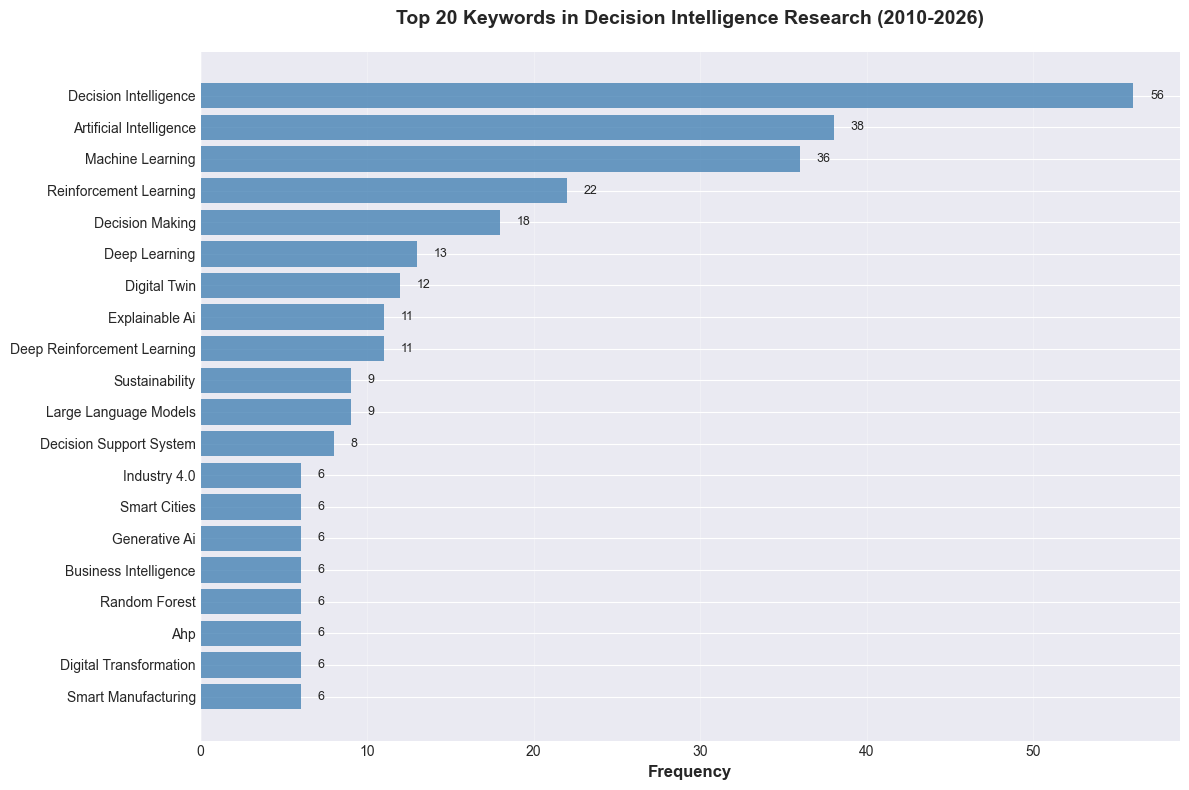

In [35]:
# Visualize top keywords
fig, ax = plt.subplots(figsize=(12, 8))

keywords_plot = [kw for kw, _ in top_keywords[:20]]
counts_plot = [count for _, count in top_keywords[:20]]

bars = ax.barh(keywords_plot, counts_plot, color='steelblue', alpha=0.8)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Keywords in Decision Intelligence Research (2010-2026)', 
             fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, counts_plot)):
    ax.text(count + 1, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top-keywords.png', dpi=300, bbox_inches='tight')
print(f"✓ Visualization saved: {OUTPUT_DIR / 'top-keywords.png'}")
plt.show()

## 5. Temporal Keyword Trends

In [36]:
# Select top keywords for trend analysis
trending_keywords = [kw for kw, _ in top_keywords[:10]]

# Create temporal data with normalized keywords
keyword_by_year = defaultdict(lambda: defaultdict(int))

for _, row in df.iterrows():
    year = row['year']
    for keyword in row['all_keywords']:
        normalized_kw = normalize_keyword(keyword)
        if normalized_kw in trending_keywords:
            keyword_by_year[year][normalized_kw] += 1

# Convert to DataFrame
years = sorted(keyword_by_year.keys())
trend_data = []

for year in years:
    row_data = {'year': year}
    for keyword in trending_keywords:
        row_data[keyword] = keyword_by_year[year].get(keyword, 0)
    trend_data.append(row_data)

trends_df = pd.DataFrame(trend_data)
trends_df = trends_df.set_index('year')

print(f"✓ Temporal trends calculated for {len(trending_keywords)} keywords")
print(f"  Year range: {trends_df.index.min():.0f} - {trends_df.index.max():.0f}")

✓ Temporal trends calculated for 10 keywords
  Year range: 2017 - 2026


✓ Visualization saved: output/keyword-temporal-trends.png


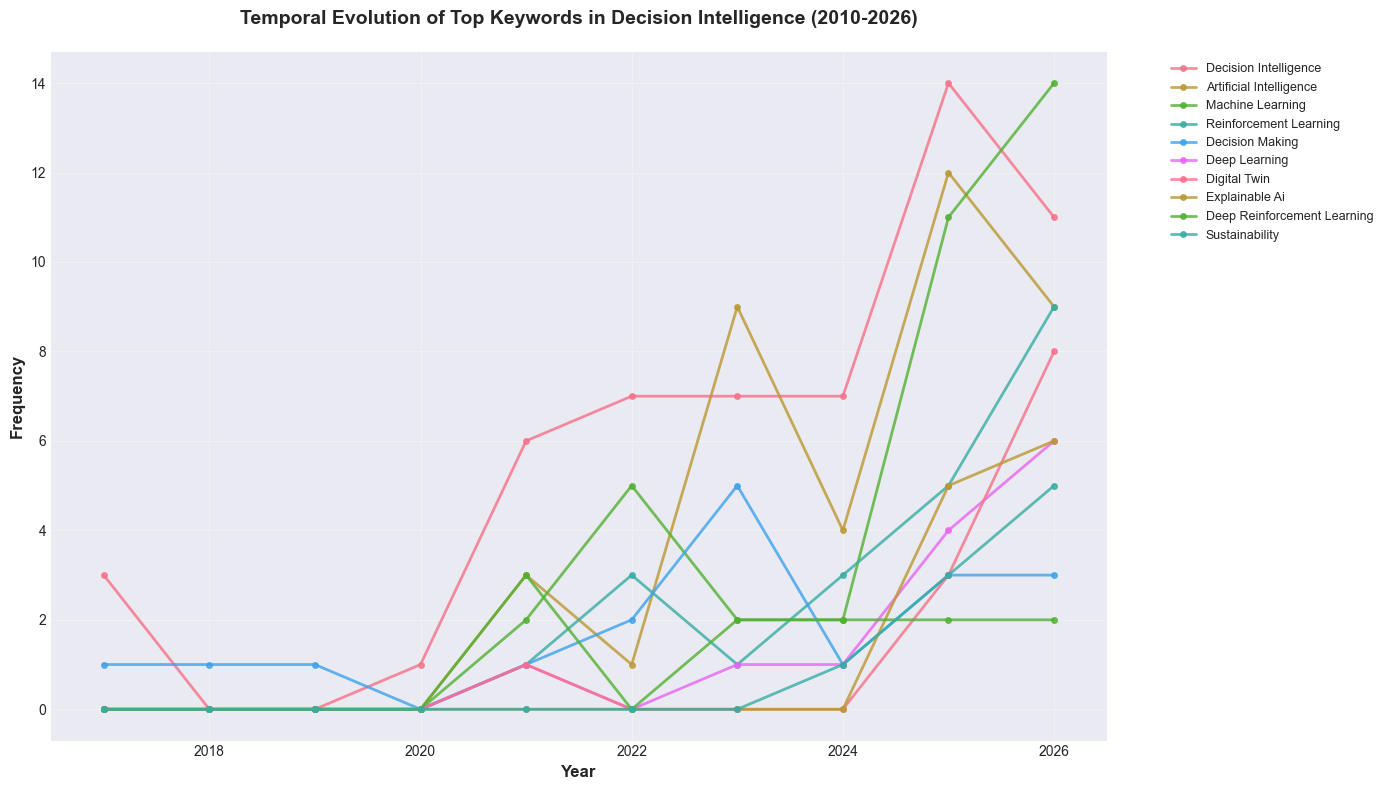

✓ Trends data saved: output/keyword_trends_by_year.csv


In [37]:
# Visualize temporal trends
fig, ax = plt.subplots(figsize=(14, 8))

for keyword in trending_keywords:
    ax.plot(trends_df.index, trends_df[keyword], marker='o', 
            label=keyword, linewidth=2, markersize=4, alpha=0.8)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Temporal Evolution of Top Keywords in Decision Intelligence (2010-2026)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(trends_df.index.min() - 0.5, trends_df.index.max() + 0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'keyword-temporal-trends.png', dpi=300, bbox_inches='tight')
print(f"✓ Visualization saved: {OUTPUT_DIR / 'keyword-temporal-trends.png'}")
plt.show()

# Save trends data
trends_df.to_csv(OUTPUT_DIR / 'keyword_trends_by_year.csv')
print(f"✓ Trends data saved: {OUTPUT_DIR / 'keyword_trends_by_year.csv'}")

## 6. Keyword Co-occurrence Analysis

In [38]:
# Calculate co-occurrence matrix for top keywords
cooccurrence_keywords = [kw for kw, _ in top_keywords[:15]]

# Initialize co-occurrence matrix
cooccurrence_matrix = defaultdict(lambda: defaultdict(int))

# Count co-occurrences with normalized keywords
for keywords in df['all_keywords']:
    # Normalize and filter to only include our target keywords
    normalized_keywords = [normalize_keyword(kw) for kw in keywords]
    relevant_keywords = [kw for kw in normalized_keywords if kw in cooccurrence_keywords]
    
    # Count all pairs
    for kw1, kw2 in combinations(relevant_keywords, 2):
        cooccurrence_matrix[kw1][kw2] += 1
        cooccurrence_matrix[kw2][kw1] += 1

# Convert to DataFrame
cooc_df = pd.DataFrame(0, index=cooccurrence_keywords, columns=cooccurrence_keywords)

for kw1 in cooccurrence_keywords:
    for kw2 in cooccurrence_keywords:
        if kw1 != kw2:
            cooc_df.loc[kw1, kw2] = cooccurrence_matrix[kw1].get(kw2, 0)

print(f"✓ Co-occurrence matrix calculated")
print(f"  Matrix size: {len(cooccurrence_keywords)} x {len(cooccurrence_keywords)}")
print(f"  Total co-occurrences: {cooc_df.sum().sum() / 2:.0f}")

# Save co-occurrence matrix
cooc_df.to_csv(OUTPUT_DIR / 'keyword_cooccurrence_matrix.csv')
print(f"✓ Co-occurrence matrix saved: {OUTPUT_DIR / 'keyword_cooccurrence_matrix.csv'}")

✓ Co-occurrence matrix calculated
  Matrix size: 15 x 15
  Total co-occurrences: 82
✓ Co-occurrence matrix saved: output/keyword_cooccurrence_matrix.csv


In [ ]:
# Visualize co-occurrence heatmap
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(cooc_df, annot=True, fmt='g', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'label': 'Co-occurrence Count'},
            ax=ax)

ax.set_title('Keyword Co-occurrence Matrix in Decision Intelligence Research', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'keyword-cooccurrence-heatmap.png', dpi=300, bbox_inches='tight')
print(f"✓ Visualization saved: {OUTPUT_DIR / 'keyword-cooccurrence-heatmap.png'}")
plt.show()

## 7. Keyword Co-occurrence Network Visualization (VOSviewer-style)

In [39]:
# Create network graph from co-occurrence data
# Use top 20 keywords for cleaner visualization
network_keywords = [kw for kw, _ in top_keywords[:20]]

# Build graph
G = nx.Graph()

# Add nodes with size based on frequency
keyword_freq = {kw: count for kw, count in top_keywords[:20]}
for keyword in network_keywords:
    G.add_node(keyword, size=keyword_freq[keyword])

# Add edges with weight based on co-occurrence strength
# Only add edges with significant co-occurrence (threshold: 2)
min_cooccurrence = 2

for kw1 in network_keywords:
    for kw2 in network_keywords:
        if kw1 < kw2:  # Avoid duplicates
            if kw1 in cooc_df.index and kw2 in cooc_df.columns:
                weight = cooc_df.loc[kw1, kw2]
                if weight >= min_cooccurrence:
                    G.add_edge(kw1, kw2, weight=weight)

print(f"✓ Network graph created")
print(f"  Nodes (keywords): {G.number_of_nodes()}")
print(f"  Edges (co-occurrences): {G.number_of_edges()}")
print(f"  Minimum co-occurrence threshold: {min_cooccurrence}")

✓ Network graph created
  Nodes (keywords): 20
  Edges (co-occurrences): 19
  Minimum co-occurrence threshold: 2


✓ Network visualization saved: output/keyword-network-graph.png


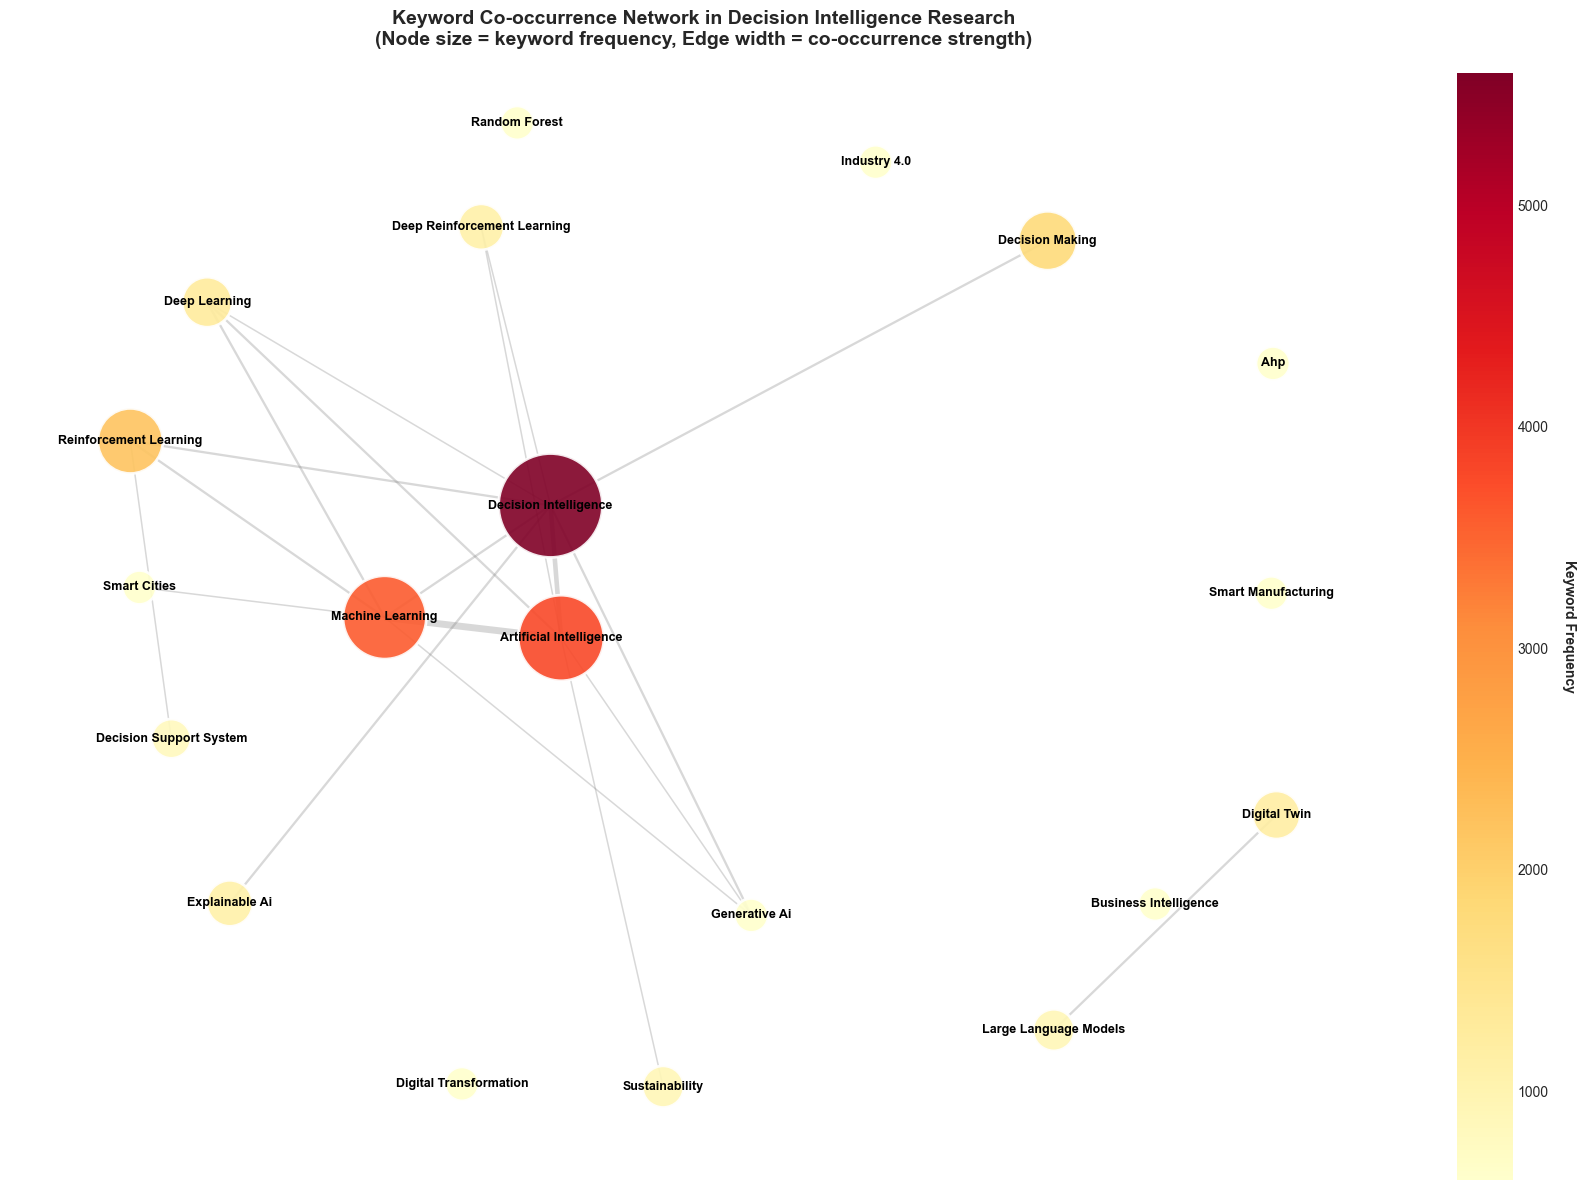

In [40]:
# Create VOSviewer-style network visualization with curved edges
fig, ax = plt.subplots(figsize=(16, 12))

# Use spring layout for better node distribution
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Calculate node sizes based on keyword frequency
node_sizes = [G.nodes[node]['size'] * 100 for node in G.nodes()]

# Calculate edge widths based on co-occurrence strength
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights) if weights else 1
edge_widths = [w / max_weight * 5 for w in weights]

# Draw curved edges using Bezier curves
from matplotlib.patches import FancyArrowPatch

for (u, v), width in zip(edges, edge_widths):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    
    # Create curved edge using ConnectionStyle
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle="arc3,rad=0.2",  # rad controls the curvature
        arrowstyle="-",
        linewidth=width,
        alpha=0.3,
        color='gray'
    )
    ax.add_patch(arrow)

# Draw nodes with color gradient based on frequency (drawn after edges for proper layering)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_sizes,
                       cmap='YlOrRd', alpha=0.9, edgecolors='white', linewidths=2, ax=ax)

# Draw labels with better visibility
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_color='black', ax=ax)

# Add title
ax.set_title('Keyword Co-occurrence Network in Decision Intelligence Research\n' +
             '(Node size = keyword frequency, Edge width = co-occurrence strength)',
             fontsize=14, fontweight='bold', pad=20)

# Remove axes
ax.axis('off')

# Add colorbar
from matplotlib.colors import Normalize
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=min(node_sizes), vmax=max(node_sizes)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Keyword Frequency', rotation=270, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'keyword-network-graph.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Network visualization saved: {OUTPUT_DIR / 'keyword-network-graph.png'}")
plt.show()

In [ ]:
# Calculate and display network metrics
print("\n📊 Network Analysis Metrics:")
print("="*60)

# Degree centrality (most connected keywords)
degree_centrality = nx.degree_centrality(G)
top_central = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\n🔗 Most Connected Keywords (Degree Centrality):")
for i, (keyword, centrality) in enumerate(top_central, 1):
    print(f"  {i}. {keyword:30s} {centrality:.3f}")

# Betweenness centrality (bridge keywords)
if G.number_of_edges() > 0:
    betweenness = nx.betweenness_centrality(G)
    top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\n🌉 Bridge Keywords (Betweenness Centrality):")
    for i, (keyword, centrality) in enumerate(top_between, 1):
        print(f"  {i}. {keyword:30s} {centrality:.3f}")

# Clustering coefficient
if G.number_of_edges() > 0:
    avg_clustering = nx.average_clustering(G)
    print(f"\n📈 Network Clustering Coefficient: {avg_clustering:.3f}")
    print("   (Higher values indicate more tightly clustered research themes)")

# Network density
density = nx.density(G)
print(f"\n🕸️  Network Density: {density:.3f}")
print("   (Proportion of possible connections that exist)")
print("\n" + "="*60)

## 8. Top Co-occurring Keyword Pairs

In [ ]:
# Extract top co-occurring pairs
cooc_pairs = []

for kw1 in cooccurrence_keywords:
    for kw2 in cooccurrence_keywords:
        if kw1 < kw2:  # Avoid duplicates
            count = cooc_df.loc[kw1, kw2]
            if count > 0:
                cooc_pairs.append((kw1, kw2, count))

# Sort by count
cooc_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"\n📊 Top 20 Co-occurring Keyword Pairs:")
print("="*70)
for i, (kw1, kw2, count) in enumerate(cooc_pairs[:20], 1):
    print(f"{i:2d}. {kw1:20s} + {kw2:20s} : {count:3d} documents")

# Save to CSV
cooc_pairs_df = pd.DataFrame(cooc_pairs, columns=['keyword1', 'keyword2', 'count'])
cooc_pairs_df.to_csv(OUTPUT_DIR / 'top_cooccurring_pairs.csv', index=False)
print(f"\n✓ Co-occurring pairs saved: {OUTPUT_DIR / 'top_cooccurring_pairs.csv'}")

## 9. Summary Statistics

In [ ]:
print("="*80)
print("KEYWORD ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATASET OVERVIEW")
print(f"  Total documents analyzed: {len(df)}")
print(f"  Documents with keywords: {(df['all_keywords'].apply(len) > 0).sum()}")
print(f"  Total unique keywords: {len(keyword_counts)}")
print(f"  Average keywords per document: {df['all_keywords'].apply(len).mean():.1f}")

print(f"\n🔑 TOP KEYWORDS")
print(f"  Most frequent keyword: {top_keywords[0][0]} ({top_keywords[0][1]} occurrences)")
print(f"  Keywords appearing in >10% of docs: {sum(1 for _, count in top_keywords if count > len(df)*0.1)}")

print(f"\n🔗 CO-OCCURRENCE ANALYSIS")
print(f"  Total keyword pairs analyzed: {len(cooccurrence_keywords)}")
print(f"  Total co-occurrences found: {len(cooc_pairs)}")
print(f"  Strongest pair: {cooc_pairs[0][0]} + {cooc_pairs[0][1]} ({cooc_pairs[0][2]} docs)")

print(f"\n📈 TEMPORAL TRENDS")
print(f"  Years analyzed: {trends_df.index.min():.0f} - {trends_df.index.max():.0f}")
print(f"  Keywords tracked over time: {len(trending_keywords)}")

print(f"\n🕸️  NETWORK ANALYSIS")
print(f"  Network nodes: {G.number_of_nodes()}")
print(f"  Network edges: {G.number_of_edges()}")
print(f"  Network density: {density:.3f}")

print(f"\n💾 OUTPUT FILES GENERATED")
print(f"  - top_keywords.csv")
print(f"  - keyword_trends_by_year.csv")
print(f"  - keyword_cooccurrence_matrix.csv")
print(f"  - top_cooccurring_pairs.csv")
print(f"  - top-keywords.png")
print(f"  - keyword-temporal-trends.png")
print(f"  - keyword-cooccurrence-heatmap.png")
print(f"  - keyword-network-graph.png")

print("\n" + "="*80)
print("✅ KEYWORD ANALYSIS COMPLETE!")
print("="*80)